# Projet Covid19 : Pipeline de Préprocessing

## 1. Présentation du dataset

Ce projet utilise le dataset COVID-19 Radiography Dataset : https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database  
Il contient des radiographies pulmonaires réparties en quatre classes :

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia

Chaque classe contient un dossier `images` avec les radiographies et un dossier `masks` avec les masques pulmonaires associés.

## 2. Environnement

In [1]:
#Vérification de l'environnement de travail

import sys
print(sys.executable)

C:\Users\n_a_e\anaconda3\envs\covid19_env\python.exe


In [2]:
# Chargement des bibliothèques

from pathlib import Path
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil

In [3]:
# Chemins d'accés

data_path = Path("../../../COVID-19_Radiography_Dataset")
classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

print("Chemin absolu :", data_path.resolve())
print("Dossier trouvé :", data_path.exists())

Chemin absolu : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset
Dossier trouvé : True


## 3. Suppression des doublons et outliers

### 3.1 Identification des doublons et outliers

In [4]:
doublons = {
    "COVID": [
        140, 591, 158, 160, 229, 21, 376, 403, 224, 232, 234, 237, 1261, 253, 572,
        1299, 761, 599, 52, 729, 1296, 214, 517, 1078, 1111, 594, 1138, 420, 344,
        602, 227, 532, 624, 768, 758, 169, 724, 1126, 1335, 483, 235, 548, 100,
        178, 181, 190, 525, 633, 372, 766, 1096, 520, 247, 567, 230, 540, 752,
        250, 569, 782, 139, 786, 614, 392, 641, 270, 619, 522, 220, 764, 1167,
        744, 492, 487, 529, 731, 514, 316, 1376, 1373, 792, 1087, 340, 1428, 280,
        419, 848, 1359, 494, 1314, 1443, 497, 1320, 755, 1332, 738, 1326, 355,
        1431, 321, 1123, 1416, 1194, 1188, 428, 463, 1244, 1437, 846, 1440, 595,
        1099, 538, 541, 951, 535, 543, 644, 469, 684, 486, 1452, 794, 1350, 820,
        1356, 873, 1362, 1469, 1264, 1267, 1276, 1279, 1285, 1288, 609, 1291,
        1466, 1353, 695, 1379, 1341, 1407, 1338, 1434, 1344, 1347, 1389, 1392,
        1395, 1425, 1455, 898, 804, 1458, 1511, 1404, 1526, 1410, 1472, 770,
        1323, 1228, 1574, 1367, 1370, 1422, 1413, 1419, 1505, 1386, 1446, 1449,
        1461, 1520, 1553, 1448, 2085, 2418, 2420, 2421, 2423, 2432, 2459, 2493,
        2667, 2678, 2716, 2717, 2718, 2719, 2773, 2774, 2805, 2808, 2809, 2810,
        2811, 2812, 2813, 2823, 2942, 2946, 3141, 3142, 3143, 3144, 3208, 3212,
        3223, 3299, 3374, 3375, 3376, 3403, 3427, 3429, 3489, 3516, 3548, 3574,
        3591, 3599
    ],
    "Normal": [818],
    "Lung_Opacity": [],
    "Viral Pneumonia": [75, 118, 250, 295, 596, 954, 1053]
}

In [6]:
print("Nombre de doublons à supprimer :")
for classe, liste in doublons.items():
    print(f"{classe:<18}: {len(liste)}")

print()

Nombre de doublons à supprimer :
COVID             : 223
Normal            : 1
Lung_Opacity      : 0
Viral Pneumonia   : 7



In [10]:
outliers = {
    "COVID": [
        324, 500, 585, 1141, 1401, 1413, 1553, 1703, 1730,
        1740, 1742, 2471, 2492, 2493, 2647, 2688, 2750,
        3480, 3584, 3615, 3342, 1179, 1876
    ],

    "Normal": [
        1485, 1530, 1591, 1834, 2287, 2857, 3068, 3117,
        3251, 3336, 3341, 3344, 3777, 3795, 3872, 3906,
        3921, 4355, 4820, 4869, 5188, 5207, 5224, 5400,
        5411, 5422, 5545, 5674, 6128, 6209, 6811, 7213,
        7383, 7501, 7516, 7619, 7634, 7764, 7826, 7859,
        7887, 7932, 8217, 8295, 8694, 8729, 8749, 9147,
        9381, 9390, 9997, 10146, 4213, 4206, 2001
    ],

    "Lung_Opacity": [
        12, 66, 191, 306, 588, 889, 1212, 1657, 2282,
        2617, 2731, 2959, 2982, 3395, 3560, 3570,
        3608, 4351, 4540, 4776, 4791, 4871, 4872, 5013
    ],

    "Viral Pneumonia": []
}

In [7]:
print("Nombre d'outliers à supprimer :")
for classe, liste in outliers.items():
    print(f"{classe:<18}: {len(liste)}")

Nombre d'outliers à supprimer :
COVID             : 23
Normal            : 55
Lung_Opacity      : 24
Viral Pneumonia   : 0


### 3.2 Définition des fonctions

In [6]:
def supprimer_fichiers(data_path, fichiers_a_supprimer, dry_run=False):

    rapport = []

    for classe, numeros in fichiers_a_supprimer.items():

        for num in numeros:

            filename = f"{classe}-{num}.png"

            image_path = data_path / classe / "images" / filename
            mask_path = data_path / classe / "masks" / filename

            for file_path, type_fichier in [
                (image_path, "image"),
                (mask_path, "mask")
            ]:

                existe = file_path.exists()

                if existe and not dry_run:
                    file_path.unlink()

                rapport.append({
                    "classe": classe,
                    "numero": num,
                    "fichier": filename,
                    "type": type_fichier,
                    "existe": existe,
                    "supprime": existe and not dry_run
                })

    return pd.DataFrame(rapport)

In [7]:
def compter_dataset(data_path):

    classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

    resultat = []

    for classe in classes:

        images = list((data_path/classe/"images").glob("*.png"))
        masks  = list((data_path/classe/"masks").glob("*.png"))

        resultat.append({
            "classe": classe,
            "nb_images": len(images),
            "nb_masks": len(masks)
        })

    return pd.DataFrame(resultat)

### 3.3 Suppression des doublons

In [11]:
print("État initial")
compter_dataset(data_path)

État initial


,classe,nb_images,nb_masks
0,COVID,3616,3616
1,Normal,10192,10192
2,Lung_Opacity,6012,6012
3,Viral Pneumonia,1345,1345


In [12]:
rapport_doublons = supprimer_fichiers(
    data_path,
    doublons,
    dry_run=False
)

print("État après suppression des doublons")
compter_dataset(data_path)

État après suppression des doublons


,classe,nb_images,nb_masks
0,COVID,3393,3393
1,Normal,10191,10191
2,Lung_Opacity,6012,6012
3,Viral Pneumonia,1338,1338


### 3.4 Suppression des outliers

In [13]:
rapport_outliers = supprimer_fichiers(
    data_path,
    outliers,
    dry_run=False
)

print("État final")
compter_dataset(data_path)

État final


,classe,nb_images,nb_masks
0,COVID,3373,3373
1,Normal,10136,10136
2,Lung_Opacity,5988,5988
3,Viral Pneumonia,1338,1338


## 4. Resize et application des masques 

In [13]:
# Dossier de sortie
output_path = Path("../../../COVID-19_Radiography_Dataset_processed")
output_path.mkdir(exist_ok=True)

In [20]:
# Application

# Taille finale des images
target_size = (299, 299)

for class_name in classes:
    
    images_dir = data_path / class_name / "images"
    masks_dir = data_path / class_name / "masks"
    
    output_class_dir = output_path / class_name / "masked_images"
    output_class_dir.mkdir(parents=True, exist_ok=True)
    
    image_files = sorted(images_dir.glob("*.png"))
    
    for img_path in image_files:
        
        mask_path = masks_dir / img_path.name
        
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Image non lisible : {img_path}")
            continue
        
        if mask is None:
            print(f"Masque manquant ou non lisible : {mask_path}")
            continue

        # ======================================================
        # Resize de l'image
        # ======================================================
        img_resized = cv2.resize(
            img,
            target_size,
            interpolation=cv2.INTER_AREA
        )

        # ======================================================
        # Resize du masque
        # ======================================================
        mask_resized = cv2.resize(
            mask,
            target_size,
            interpolation=cv2.INTER_NEAREST
        )
        
        # ======================================================
        # Binarisation du masque
        # ======================================================
        mask_binary = np.where(
            mask_resized > 0,
            255,
            0
        ).astype(np.uint8)
        
        # ======================================================
        # Application du masque
        # ======================================================
        masked_img = cv2.bitwise_and(
            img_resized,
            img_resized,
            mask=mask_binary
        )
        
        # ======================================================
        # Sauvegarde
        # ======================================================
        output_file = output_class_dir / img_path.name
        cv2.imwrite(str(output_file), masked_img)

print("Traitement terminé.")
print("Images masquées enregistrées dans :", output_path.resolve())

Traitement terminé.
Images masquées enregistrées dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed


In [21]:
# Vérification

masked_dir = Path("../../../COVID-19_Radiography_Dataset_processed") / "COVID" / "masked_images"

print(masked_dir)
print(masked_dir.exists())

if masked_dir.exists():
    print(list(masked_dir.iterdir())[:10])

..\..\..\COVID-19_Radiography_Dataset_processed\COVID\masked_images
True
[WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-10.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1000.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1001.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1002.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1003.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1004.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1005.png'), WindowsPath('../../../COVID-19_Radiography_Dataset_processed/COVID/masked_images/COVID-1006.png'), WindowsPath('../../../COVID-19_Radiograp

## 5. Normalisation par equalizehist et CLAHE

In [23]:
input_path = output_path      
output_eq = Path("../../../COVID-19_Radiography_Dataset_equalizeHist")
output_clahe = Path("../../../COVID-19_Radiography_Dataset_CLAHE")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

clahe = cv2.createCLAHE(
    clipLimit=10,
    tileGridSize=(8, 8)
)

for class_name in classes:

    input_dir = input_path / class_name / "masked_images"

    output_eq_dir = output_eq / class_name
    output_clahe_dir = output_clahe / class_name

    output_eq_dir.mkdir(parents=True, exist_ok=True)
    output_clahe_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(input_dir.glob("*.png"))

    for img_path in image_files:

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Image non lisible : {img_path}")
            continue

        # =====================================================
        # Egalisation globale de l'histogramme
        # =====================================================
        img_eq = cv2.equalizeHist(img)

        cv2.imwrite(
            str(output_eq_dir / img_path.name),
            img_eq
        )

        # =====================================================
        # CLAHE
        # =====================================================
        img_clahe = clahe.apply(img_eq)

        cv2.imwrite(
            str(output_clahe_dir / img_path.name),
            img_clahe
        )

print("Normalisation terminée.")

Normalisation terminée.


In [5]:
# Vérification

norm_dir = Path("../../../COVID-19_Radiography_Dataset_CLAHE")

print(norm_dir)
print(norm_dir.exists())

if norm_dir.exists():
    print(list(norm_dir.iterdir())[:10])

..\..\..\COVID-19_Radiography_Dataset_CLAHE
True
[WindowsPath('../../../COVID-19_Radiography_Dataset_CLAHE/COVID'), WindowsPath('../../../COVID-19_Radiography_Dataset_CLAHE/Lung_Opacity'), WindowsPath('../../../COVID-19_Radiography_Dataset_CLAHE/Normal'), WindowsPath('../../../COVID-19_Radiography_Dataset_CLAHE/Viral Pneumonia')]


## 6. Split du dataset : Train, Validation et Test

In [6]:
# Création des listes d'images

dataset_path = Path("../../../COVID-19_Radiography_Dataset_CLAHE")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

data = []

for classe in classes:

    images_dir = dataset_path / classe

    for img_path in images_dir.glob("*.png"):

        data.append({
            "filepath": img_path,
            "class": classe
        })

df = pd.DataFrame(data)

df.head()

,filepath,class
0,..\..\..\COVID-19_Radiography_Dataset_CLAHE\CO...,COVID
1,..\..\..\COVID-19_Radiography_Dataset_CLAHE\CO...,COVID
2,..\..\..\COVID-19_Radiography_Dataset_CLAHE\CO...,COVID
3,..\..\..\COVID-19_Radiography_Dataset_CLAHE\CO...,COVID
4,..\..\..\COVID-19_Radiography_Dataset_CLAHE\CO...,COVID


In [7]:
# Split des données (80% en Train, 10% en validation et 10% en test)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

In [8]:
# Vérification des effectifs

print("Train")
print(train_df["class"].value_counts())

print()

print("Validation")
print(val_df["class"].value_counts())

print()

print("Test")
print(test_df["class"].value_counts())

print("Nombre total :", len(df))
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train
class
Normal             8109
Lung_Opacity       4791
COVID              2698
Viral Pneumonia    1070
Name: count, dtype: int64

Validation
class
Normal             1013
Lung_Opacity        598
COVID               338
Viral Pneumonia     134
Name: count, dtype: int64

Test
class
Normal             1014
Lung_Opacity        599
COVID               337
Viral Pneumonia     134
Name: count, dtype: int64
Nombre total : 20835
Train : 16668
Validation : 2083
Test : 2084


In [18]:
print("Nombre total :", len(df))
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Nombre total : 20835
Train : 16668
Validation : 2083
Test : 2084


In [19]:
# Définition du réseau

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    shear_range=5,
    horizontal_flip=True,
    fill_mode="nearest"
)

## 7. Data augmentation

In [20]:
train_df["filepath"] = train_df["filepath"].astype(str)
val_df["filepath"] = val_df["filepath"].astype(str)
test_df["filepath"] = test_df["filepath"].astype(str)

In [21]:
# Création du générateur d'entraînement avec data augmentation

BATCH_SIZE = 16
IMAGE_SIZE = (299, 299)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 16668 validated image filenames belonging to 4 classes.


In [22]:
print(train_generator.class_indices)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


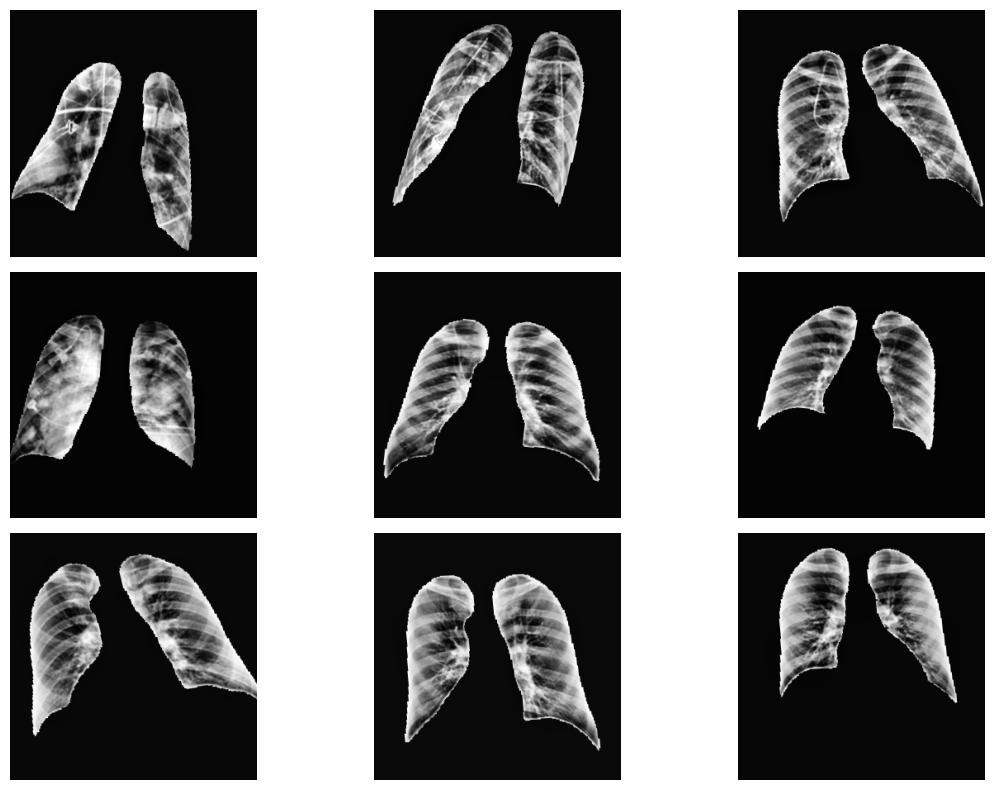

In [17]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Export des données Train non augmentées, Validation et Test

In [25]:
split_output_path = Path("../../../COVID-19_Radiography_Dataset_split")

def exporter_split(df_split, split_name, output_path):
    
    for _, row in df_split.iterrows():
        
        src_path = Path(row["filepath"])
        classe = row["class"]
        
        dest_dir = output_path / split_name / classe
        dest_dir.mkdir(parents=True, exist_ok=True)
        
        dest_path = dest_dir / src_path.name
        
        shutil.copy2(src_path, dest_path)

    print(f"{split_name} exporté : {len(df_split)} images")


# Export des trois jeux
exporter_split(train_df, "train", split_output_path)
exporter_split(val_df, "validation", split_output_path)
exporter_split(test_df, "test", split_output_path)

train exporté : 16668 images
validation exporté : 2083 images
test exporté : 2084 images


## 8. Export des données Train augmentées

In [16]:
# Dossier de sortie
train_augmented_path = split_output_path / "train_augmented"

# Nombre d'images augmentées générées par image originale
N_AUG = 1

# Création des dossiers de classes
for classe in classes:
    (train_augmented_path / classe).mkdir(parents=True, exist_ok=True)

# 1. Copie des images originales dans train_augmented
for _, row in train_df.iterrows():
    src = Path(row["filepath"])
    dst = train_augmented_path / row["class"] / src.name
    shutil.copy2(src, dst)

print("Images originales copiées dans train_augmented.")

Images originales copiées dans train_augmented.


In [23]:
# Générateur dédié à l'export des images augmentées
export_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=1,
    shuffle=False
)

Found 16668 validated image filenames belonging to 4 classes.


In [24]:
# Génération et sauvegarde des images augmentées

for aug_idx in range(1, N_AUG + 1):
    
    export_generator.reset()
    
    for i in range(len(train_df)):
        
        image, label = next(export_generator)
        
        img = image[0].squeeze()
        
        # Conversion en uint8 si nécessaire
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
        
        classe = train_df.iloc[i]["class"]
        original_path = Path(train_df.iloc[i]["filepath"])
        original_stem = original_path.stem
        
        output_file = train_augmented_path / classe / f"{original_stem}_aug{aug_idx}.png"
        
        cv2.imwrite(str(output_file), img)

print("Images augmentées enregistrées dans :", train_augmented_path.resolve())

Images augmentées enregistrées dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split\train_augmented


## 9. Vérification des exports

In [27]:
def compter_split(split_output_path):

    lignes = []

    for split_name in ["train", "train_augmented", "validation", "test"]:

        split_dir = split_output_path / split_name

        for classe in classes:

            classe_dir = split_dir / classe

            nb_images = len(list(classe_dir.glob("*.png"))) if classe_dir.exists() else 0

            lignes.append({
                "split": split_name,
                "classe": classe,
                "nb_images": nb_images
            })

    return pd.DataFrame(lignes)


display(compter_split(split_output_path))

,split,classe,nb_images
0,train,COVID,2698
1,train,Normal,8109
2,train,Lung_Opacity,4791
3,train,Viral Pneumonia,1070
4,train_augmented,COVID,5396
5,train_augmented,Normal,16218
6,train_augmented,Lung_Opacity,9582
7,train_augmented,Viral Pneumonia,2140
8,validation,COVID,338
9,validation,Normal,1013
